In [43]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# specify GA results folder here
ga_run = 'ga_20220906-161631'

path = 'Results/' + ga_run

In [5]:
with open(path + '/params.json') as f:
    params = json.loads(f.read())

In [48]:
fitnesses_all = []
for i in range(1, params['generations'] + 1):
    fitnesses_generation = []
    for individual in os.listdir(path + f'/Generation_{i}'):
        with open(path + f'/Generation_{i}/{individual}/results.json') as f:
            results = json.loads(f.read())
            try:
                if results['fitness'] == -100:
                    results['fitness'] = -1
                fitnesses_generation.append(results['fitness'])
            except:
                # this means that there is no fitness in the file 
                # because the model was too big and so the fitness was not determined
                fitnesses_generation.append(-1)
    fitnesses_all.append(fitnesses_generation)

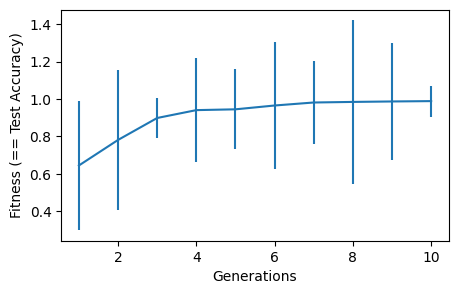

In [50]:
plt.figure(figsize=(5, 3))
plt.errorbar(np.arange(1, 11), np.median(fitnesses_all, axis=1), np.std(fitnesses_all, axis=1))
plt.xlabel('Generations')
plt.ylabel('Fitness (== Test Accuracy)')
plt.show()